## PyTorch computer vision

### 0. computer vision libraries in PyTorch

- [`torchvision`](https://docs.pytorch.org/vision/stable/index.html) - base domain library for PyTorch computer vision.

- `torchvision.datasets` - get datasets and data loading functions for computer vision.

- `torchvision.models` - get pretrained computer vision models that we can leverage for our own problems.

- `torchvision.tranforms` - for manipulating our  vision data (images) to be suitable for use with a ML model.

- `torch.utils.data.Dataset` - Base dataset class for PyTorch.

- `torch.utils.data.DataLoader` - Creates a python iterable over a dataset.


In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torchvision.io import read_image

import matplotlib.pyplot as plt
import numpy as np

# Check versions
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


### 1. Getting a dataset

- The dataset we'll be using is `FashionMNIST` from `torchvision.datasets`.

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",  # Where to download the data to?
    train=True,  # Do we want the training dataset?
    download=True, # Do we want to download it?
    transform=ToTensor(),  # How do we want to transform the data?
    target_transform=None # How do we want to transforms the labels(targets)?
)


test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.0MB/s]


In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# See the first training example
image, label = train_data[0]

image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### 1.1 Check input and output of our image

In [7]:
# Check the shape of the image
# It has only 1 color channel becuase the images are black & white
print(f"Image shape: {image.shape} --> [color channels, hieght, width]")
print(f"Image label: {label} --> {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) --> [color channels, hieght, width]
Image label: 9 --> Ankle boot


### 1.2 Visualizing

In [8]:
image, label = train_data[0]

print(f"Image shape: {image.shape}")
print(f"Image label: {label}")

Image shape: torch.Size([1, 28, 28])
Image label: 9


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

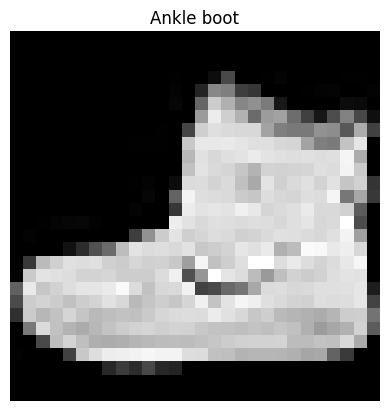

In [9]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

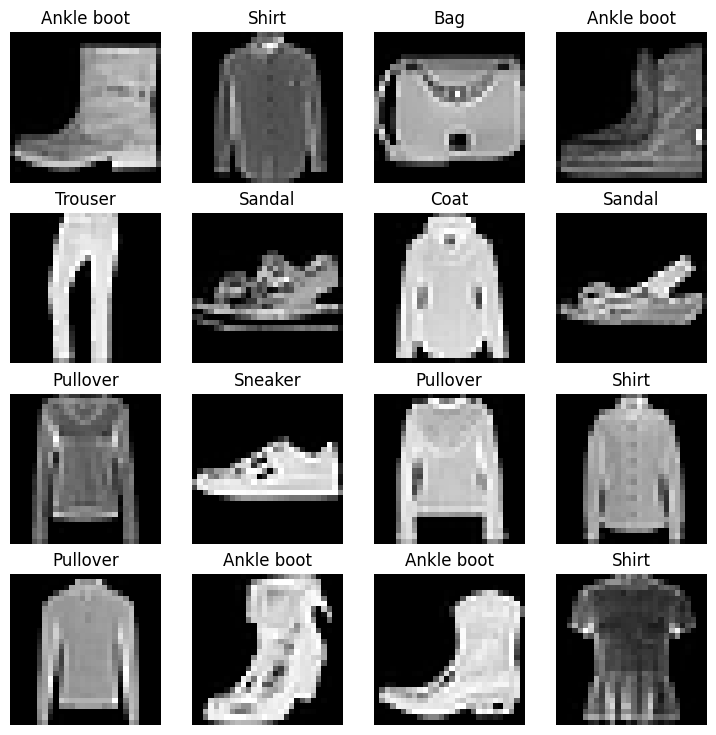

In [10]:
# Check out other images randomly
torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

Do you think these items of clothing (images) could be modelled with pure linear lines or we'll need `non-linearity`?

In [11]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

### 2. Prepare DataLoader

- Right now, our data is in the form of PyTorch Datasets.

- DataLoader turns our dataset into a python iterable.

- More specifically, we want to turn our data into batches (or mini-batches).

Why we need to do so?

1. It is more computationally efficient, as our computing hardware may not be able to look (store in memory) at 60000 images at on hit. So we break it down to 32 images at a time (batch-size = 32).

2. It gives our neural network more chances to update its gradients per epoch.




In [12]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)

# About the test dataset, the order doesn't matter as the model do not see it during the training phase, so we will
# set "shuffle = False"
test_dataloader = DataLoader(dataset=test_data, batch_size = BATCH_SIZE, shuffle=False)


train_dataloader, test_dataloader




(<torch.utils.data.dataloader.DataLoader at 0x7b05f862f230>,
 <torch.utils.data.dataloader.DataLoader at 0x7b060323df70>)

In [13]:
# Let's check what we have created

print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Length of train_dataloader: 1875 batches of 32
Length of test_dataloader: 313 batches of 32


In [14]:
# Check out what's inside the training dataloader
# iter(train_dataloader) = turns it into an iterator, so you can step through batches one by one
train_features_batch, train_labels_batch = next(iter(train_dataloader))

train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6, Shirt


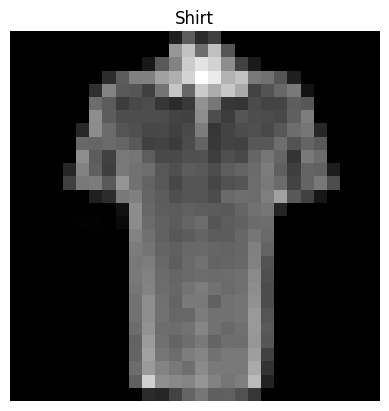

In [15]:
# Show a sample
torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label}, {class_names[label]}")


### 3. Model 0: Build a baseline model

when starting to build a series of machine learning modelling experiences, the base practice is to start with the baseline model.

A **baseline model** is a model we will try and improve upon with subsequent models/experiences.

In other words:

- Start simply and add complexity when necessary.



In [16]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
out = flatten_model(x)

# Print out what happend:
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {out.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [17]:
class FashionMNISTModel_v0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )


  def forward(self, x):
    return self.layer_stack(x)


In [18]:
torch.manual_seed(42)

# Setup model with input parameters

model_0 = FashionMNISTModel_v0(
    input_shape=784,  # This is 28*28
    hidden_units=10,  # how many units in the hidden layer
    output_shape=len(class_names)  # one for every class
    ).to('cpu')

model_0

FashionMNISTModel_v0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
# Test
dummy_x = torch.rand([1,1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [20]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss function - since we're working with multi-class data, our loss function will be `nn.CrossEntropyLoss()`

* Optimizer - our optimizer `torch.optim.SGD()` (stochastic gradient descent)

* Evaluation metric - Since we're working on a classification problem, let's use accuracy as our evaluation metric

In [21]:
from urllib import request
import requests
from pathlib import Path

# Download helper function from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


In [22]:
# Import accuracy metric

from helper_functions import accuracy_fn

# Setup loss and optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)



### 3.2. Creating a function to time our experiments

Machine learning is very experimental.

Two of main things we'll often want to track are:

1. Model performance (loss, accuracy values and etc)

2. How fast it runs

In [23]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [24]:
start_time = timer()
# Some code...
end_time = timer()
print_train_time(start=start_time, end=end_time, device='cpu')

Train time on cpu: 0.000 seconds


4.882500002167944e-05

### 3.3. Creating a training loop and training a model on batches of data

1. Loop through epochs.

2. Loop through training batches, perform training steps, calculate the train loss **per batch**.


3. Loop through testing batches, perform testing steps, calculate the test loss **per batch**.

4. Print what is happening.

5. Time it all (for us).


In [25]:
from tqdm.auto import tqdm

'''
Training:

  1- predict

  2- measure error

  3- compute gradients

  4- update weights

'''

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training time)
epochs = 3

# Create a training and testing loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  ### Training
  train_loss = 0
  # Add a loop to loop through the training batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calculate the loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss  # accumulate train loss


    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. optimizer step
    optimizer.step()

    # Print out what is happening
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

# Divide total train loss by length of train dataloader (average loss)
train_loss /= len(train_dataloader)

### Testing
test_loss, test_acc = 0, 0
model_0.eval()
with torch.inference_mode():
  for X_test, y_test in test_dataloader:
    # 1. Forward pass
    test_pred = model_0(X_test)

    # 2. Calculate loss (accumulatively)
    test_loss += loss_fn(test_pred, y_test)

    # 3. Calculate accuracy
    test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

  # Calculate the test loss average per batch
  test_loss /= len(test_dataloader)

  # Calculate the test accuracy average per batch
  test_acc /= len(test_dataloader)

# Print out what is happening
print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")


# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Epoch: 1
-------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Epoch: 2
-------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4532 | Test loss: 0.5109, Test acc: 82.3782
Train time on cpu: 26.275 seconds


### 4. Make predictions and get Model 0 results


In [26]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.dataloader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred= y_pred.argmax(dim=1))

    # Scale the loss and acc to average the loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # this only works when model was created with a class
          "model_loss": loss.item(),
          "model_acc": acc}


# Calculate model_0 results on test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel_v0',
 'model_loss': 0.5108762383460999,
 'model_acc': 82.37819488817891}

### 5. Setup device agnostic code


In [27]:
torch.cuda.is_available()

True

In [28]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### 6. Building a better model using `non-linearity`


In [29]:
# Create a model with non-linear and linear layers
class FashionMNISTModel_v1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # Flatten input into a single vector
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )


  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)



In [30]:
# Create an instance of model_1
torch.manual_seed(42)

# Setup model with input parameters

model_1 = FashionMNISTModel_v1(
    input_shape=784,  # This is 28*28
    hidden_units=10,  # how many units in the hidden layer
    output_shape=len(class_names)  # one for every class
    ).to(device)

model_0

FashionMNISTModel_v0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

### 6.1. Setup loss, optimizer and evaluation metrics

In [31]:
from helper_functions import accuracy_fn

# Setup loss and optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)


### 6.2. Training and testing loop

Let's create a function for:

- Training loop: `train_step()`

- Testing loop: `test_step()`

In [32]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0,0

  # Put model on training mode
  model.train()
  for batch, (X, y) in enumerate(data_loader):
    # Put data on target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate the loss/acc (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()  # accumulate train loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1)) # From logits to prediction labels

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Divide total train loss/acc by length of train dataloader (average loss/acc per batch)
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  return train_loss, train_acc

In [33]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  test_loss, test_acc = 0,0
  # Put model on eval mode
  model.eval()

  # Turn on inference mode context manager
  with torch.inference_mode():
    for X, y in data_loader:
      # Put data on target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred = model(X)

      # 2. Calculate the loss/acc (per batch)
      test_loss += loss_fn(test_pred, y).item()
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1)) # go from logits to prediction labels

  # Adjust metrics and print out
  test_loss /= len(data_loader)
  test_acc /= len(data_loader)
  return test_loss, test_acc

In [34]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_loss, train_acc = train_step(model=model_1,
                                       data_loader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       accuracy_fn=accuracy_fn,
                                       device=device)

    test_loss, test_acc = test_step(model=model_1,
                                    data_loader=test_dataloader,
                                    loss_fn=loss_fn,
                                    accuracy_fn=accuracy_fn,
                                    device=device)
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.0920 | Train acc: 61.3433 | Test loss: 0.9564 | Test acc: 64.9960
Epoch: 1
-------
Train loss: 0.7810 | Train acc: 71.9283 | Test loss: 0.7223 | Test acc: 73.9117
Epoch: 2
-------
Train loss: 0.6703 | Train acc: 75.9367 | Test loss: 0.6850 | Test acc: 75.0200
Train time on cuda: 32.403 seconds


In [35]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.dataloader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device=device):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      # target device
      X,y = X.to(device), y.to(device)
      # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred= y_pred.argmax(dim=1))

    # Scale the loss and acc to average the loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # this only works when model was created with a class
          "model_loss": loss.item(),
          "model_acc": acc}


In [36]:
# Get model_1 results dictionary
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)

model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel_v1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

### Model_2: Building a Convolutional Neural Network (CNN)

- CNN's are also known as ConvNets.

- CNN's are known for their capabilities to find patterns in visual data.

- To find out what's happening inside the CNN, check out this website: https://poloclub.github.io/cnn-explainer/#article-convolution

In [37]:
# Create a convolutional nueral network

# Kernel size: the size of the filter window that scans the image, such as 3×3 or 5×5.
# Stride: how many pixels the filter moves each step across the input, such as 1 or 2.
# Padding: extra pixels (usually zeros) added around the input border so the filter can cover the edges and control output size.

class FashionMNISTModel_v2(nn.Module):
  """
  model architecture that replicate the TinyVGG (from CNN explane website)
  """
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    return x

In [38]:
image.shape

torch.Size([1, 28, 28])

In [39]:
# Instantiate the model
torch.manual_seed(42)
# input shape = # color channels of the image
model_2 = FashionMNISTModel_v2(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
model_2

FashionMNISTModel_v2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 7.1. Stepping through `nn.conv2d`

- Documentation: https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

In [40]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64)).to(device)

# Create a singular image
test_image = images[0]

print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"test image\n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
test image
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
    

In [41]:
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=(3,3), stride=1, padding=0).to(device)

# Pass the data through the convolutional layer
# Point: As the conv_layer expect 4-dim input, we need to add an extra dim to the test_image --> However, in new version of pytorch, it will done automatically

# test_image = test_image.unsqueeze(dim=0)

conv_out = conv_layer(test_image)
conv_out

tensor([[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
           6.6224e-01, -2.3216e-01],
         [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
          -1.8552e-01, -5.7622e-01],
         [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
           1.4923e-01,  1.4236e-01],
         ...,
         [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
           4.2594e-01, -4.8341e-01],
         [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
          -3.6626e-01,  3.5645e-01],
         [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
          -4.9680e-01, -7.2258e-01]],

        [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
          -1.7643e+00,  2.5263e-01],
         [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
           4.8068e-01,  8.4869e-01],
         [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
           2.4611e-01,  6.6233e-01],
         ...,
         [ 9.8860e-02,  1

As we can see, the shape of the output layer changed compare to the intput which was the test_image   

In [42]:
test_image.shape, conv_out.shape

(torch.Size([3, 64, 64]), torch.Size([10, 62, 62]))

### 7.2. Stepping through `nn.MaxPool2d()`

Documentation: https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html

In [43]:
# Print out original shape without unsqueezed dimension

print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2) # equal to (2,2)

# Pass data through just conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Test image through conv_layer: {test_image_through_conv.shape}")

# Then pass data through the max pool layer
test_image_through_pool = max_pool_layer(test_image_through_conv)
print(f"Test image through max pool layer: {test_image_through_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Test image through conv_layer: torch.Size([1, 10, 62, 62])
Test image through max pool layer: torch.Size([1, 10, 31, 31])


In [44]:
# For better understanding, let's create a random tensor with a similar number of dimensions to our shape
torch.manual_seed(42)

random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"\nRandom tensor: {random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass the random tensor through it
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor: {max_pool_tensor}")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")


Random tensor: tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor: tensor([[[[0.3367]]]])
Max pool tensor shape: torch.Size([1, 1, 1, 1])


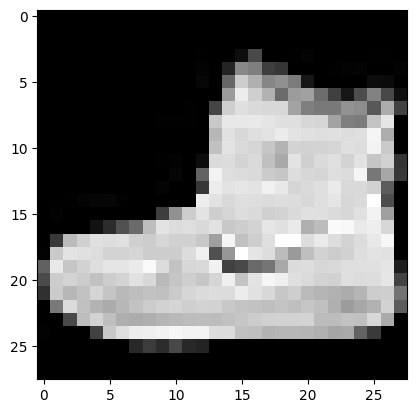

In [45]:
plt.imshow(image.squeeze(dim=0), cmap="gray")

In [46]:
# Pass the above image to the CNN model
model_2(image.unsqueeze(0).to(device))

tensor([[ 0.0246, -0.0644,  0.0551, -0.0360, -0.0139,  0.0113, -0.0014, -0.0075,
          0.0213,  0.0076]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3. Setup a loss and optimizer function for `model_2`

In [47]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

### 7.4. Create the training and testing loops for `model_2`

In [48]:
import torch
from tqdm.auto import tqdm
from timeit import default_timer as timer

# Using pre-defined training and testing functions
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
train_time_start_model_2 = timer()

# Train and test the model
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n------")
    train_loss, train_acc = train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer = optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

    test_loss, test_acc = test_step(model=model_2,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

train_time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(start=train_time_start_model_2, end=train_time_end_model_2, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Train loss: 0.5955 | Train acc: 78.3067 | Test loss: 0.3993 | Test acc: 85.7927
Epoch: 1
------
Train loss: 0.3646 | Train acc: 86.7517 | Test loss: 0.3519 | Test acc: 86.8211
Epoch: 2
------
Train loss: 0.3266 | Train acc: 88.1417 | Test loss: 0.3238 | Test acc: 87.9792
Train time on cuda: 41.165 seconds


In [49]:
# Evaluating
model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel_v2',
 'model_loss': 0.3238316476345062,
 'model_acc': 87.97923322683707}

### Compare model results and training time


In [50]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                               model_1_results,
                               model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModel_v0,0.510876,82.378195
1,FashionMNISTModel_v1,0.685001,75.019968
2,FashionMNISTModel_v2,0.323832,87.979233


In [51]:
# Add training time to results comparison
compare_results["training time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]

compare_results

,model_name,model_loss,model_acc,training time
0,FashionMNISTModel_v0,0.510876,82.378195,26.275130
1,FashionMNISTModel_v1,0.685001,75.019968,32.402929
2,FashionMNISTModel_v2,0.323832,87.979233,41.165348


Text(0, 0.5, 'Model Name')

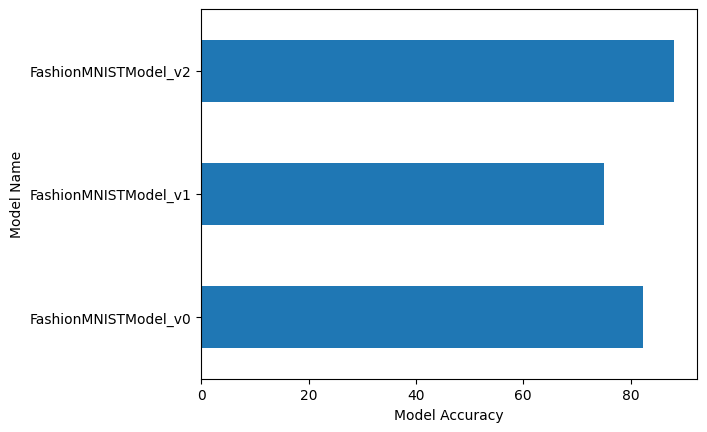

In [52]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("Model Accuracy")
plt.ylabel("Model Name")

### 9. Make and evaluate random predictions with best model

In [53]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):

  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare the sample
      sample = torch.unsqueeze(sample, dim=0).to(device)
      # Forward pass
      pred_logits = model(sample)
      # Get prediction probability
      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)
      # Get pred_prob off the GPU
      pred_probs.append(pred_prob.cpu())
  # stack the pred_probs to turn list into the tensor
  return torch.stack(pred_probs)


In [54]:
import random
# random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)


# View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Ankle boot')

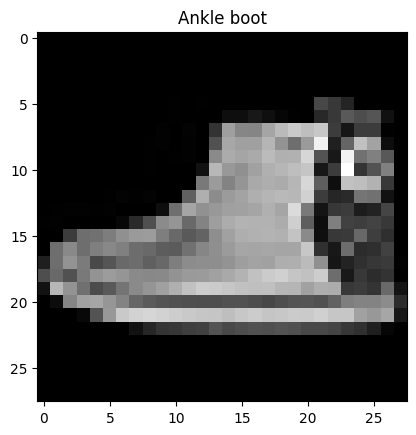

In [55]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [56]:
# Make predictions
pred_probs = make_predictions(model=model_2, data=test_samples)

# View the first 2 predictions probabilities
pred_probs[:2]

tensor([[1.8482e-05, 7.5339e-06, 4.7140e-05, 6.3891e-05, 2.2393e-05, 5.4854e-02,
         3.5924e-04, 1.5653e-02, 1.0201e-03, 9.2795e-01],
        [4.1159e-07, 8.0444e-07, 1.6524e-06, 2.4859e-05, 4.8439e-06, 4.6443e-03,
         1.9532e-07, 9.8967e-01, 8.1672e-04, 4.8359e-03]])

In [57]:
# Convert predition probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([9, 7, 5, 1, 6, 6, 0, 8, 6])

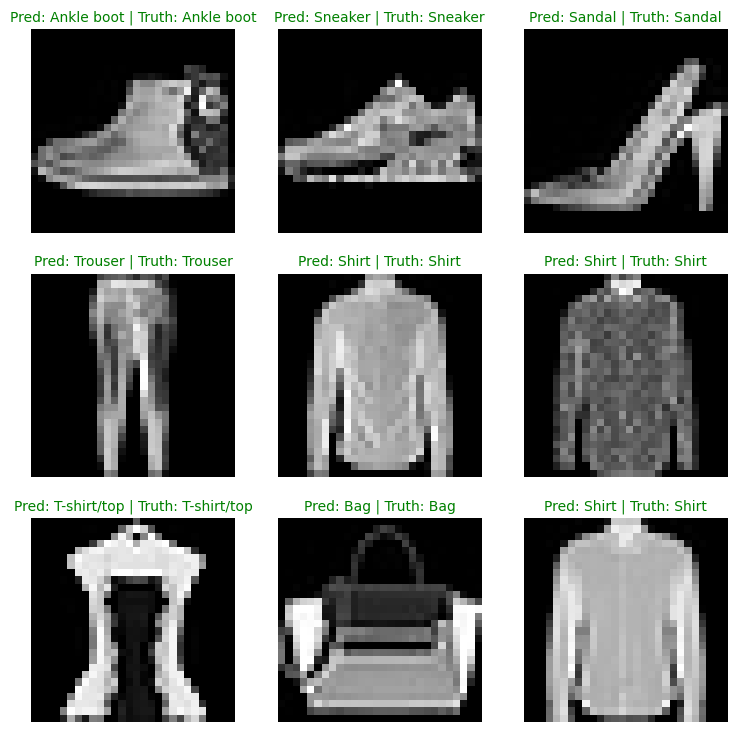

In [58]:
# Plot predictions
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows, ncols, i+1)
  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")
  # Find the prediction label
  pred_label = class_names[pred_classes[i]]
  # Get the truth label
  truth_label = class_names[test_labels[i]]

  # Create a title for the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality between pred and truth and change color of title text
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g")
  else:
    plt.title(title_text, fontsize=10, c="r")

  plt.axis(False)

### 10. Making a confusion matrix for futher prediction evaluation

A confusion matrix is a fantastic way to evaluate our classification model visually.

1. Make predictions with our trained model on the test dataset.

2. Make a confusion matrix using `torchmetrics.ConfusionMatrix`

3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

In [59]:
# Import tqdm.auto
from tqdm.auto import tqdm

# 1. Make prediction
y_preds = []
model_2.to(device)
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logits = model_2(X)
    # Turn predictions from logits --> prediction probabilities --> prediction labels
    y_pred = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim=1)
    # Put prediction on cpu
    y_preds.append(y_pred.cpu())

# Concatenate list of predictions into a tensor
# print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor, len(y_pred_tensor)


Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

(tensor([9, 2, 1,  ..., 8, 1, 2]), 10000)

In [60]:
# Installing the required packages
try:
  import torchmetrics, mlxtend
  print("torchmetrics and mlxtend are already installed")
except:
  !pip install -q torchmetrics
  import torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.9 MB/s eta 0:00:00


In [61]:
import torchmetrics
torchmetrics.__version__

'1.9.0'

In [62]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion instance and compare predictions to taegets
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)
confmat_tensor

tensor([[621,   5,  59,  74,  13,   0, 221,   0,   7,   0],
        [  8, 894,  10,  68,  15,   0,   3,   0,   1,   1],
        [  8,   1, 819,  12,  95,   0,  61,   0,   4,   0],
        [ 24,  13,  36, 843,  47,   0,  30,   0,   5,   2],
        [  4,   5, 124,  40, 722,   0,  99,   0,   6,   0],
        [  3,   1,  12,  12,   0, 825,   2,  45,  77,  23],
        [ 58,   6, 140,  58,  89,   0, 636,   0,  13,   0],
        [  1,   0,   0,   0,   0,  28,   0, 890,  15,  66],
        [  6,   1,  28,  16,  12,   7,  25,   6, 897,   2],
        [  1,   1,   2,   3,   0,  18,   3,  76,  14, 882]])

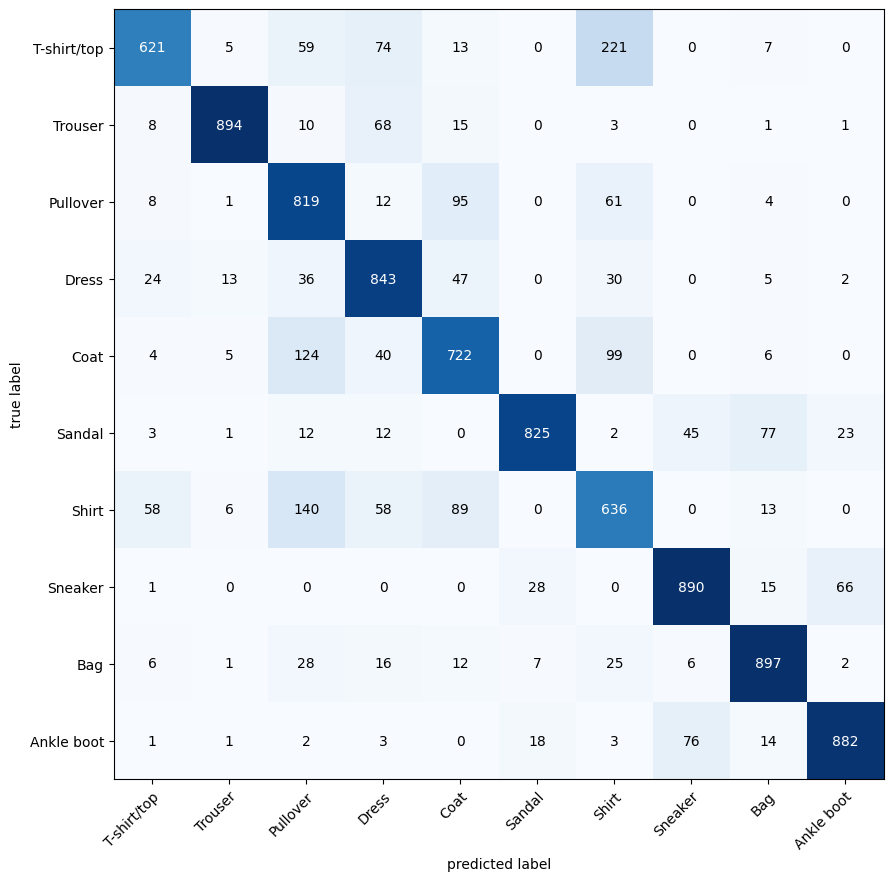

In [63]:
# Plot the confusion matrix
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                                  class_names=class_names,
                                  figsize=(10,10))

### 11. Save and load best performing model

In [64]:
from pathlib import Path

# Create model directory path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)


Saving model to: models/03_pytorch_computer_vision_model.pth


In [65]:
# Create a new instance
torch.manual_seed(42)
loaded_model_2 = FashionMNISTModel_v2(input_shape=1, hidden_units=10, output_shape=len(class_names))

# Load in the save state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send the model to target device
loaded_model_2.to(device)

FashionMNISTModel_v2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [66]:

model_2_results

{'model_name': 'FashionMNISTModel_v2',
 'model_loss': 0.3238316476345062,
 'model_acc': 87.97923322683707}

In [67]:
# Evaluate the loaded model
torch.manual_seed(42)
loaded_model_2_results = eval_model(model=loaded_model_2,
                                    data_loader=test_dataloader,
                                    loss_fn=loss_fn,
                                    accuracy_fn=accuracy_fn,
                                    device=device)

loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel_v2',
 'model_loss': 0.3238316476345062,
 'model_acc': 87.97923322683707}

In [68]:
# Check if the model results are close together
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-02)

tensor(True)